<a href="https://colab.research.google.com/github/paluigi-moltis/index-calculation-python/blob/main/Index_Calculation_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Index calculation in Python

Examples with some open scanner data using the **PyIndexNum** package.

This notebook is a Python translation of the [*Index calculation in R*](https://github.com/UN-Task-Team-for-Scanner-Data/brazil-workshop-on-use-of-ads/blob/multilateral/Index_Calculation_in_R.ipynb) notebook, using [PyIndexNum](https://github.com/paluigi/PyIndexNum) instead of `PriceIndices` and `IndexNumR`.


# Preparation

In order to calculate indices in Python we need to install the **PyIndexNum** package, which is not pre-installed in Google Colab.


In [1]:
# Install required packages
%pip install pyindexnum matplotlib -q


/home/ubuntu/coding/index-calculation-python/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


This notebook uses the **PyIndexNum** package, which is able to calculate both bilateral and multilateral indices. In addition we use popular packages for data manipulation and visualisation.


In [2]:
import polars as pl        # for data manipulation
import pyindexnum as pin   # for price index calculations
import matplotlib.pyplot as plt  # for graphics
import re                  # for text processing


## Dataset

We use data from a set of food prices in Italian supermarkets provided by Banca d'Italia, Università Campus Bio-Medico and Università degli Studi della Tuscia. The complete dataset is available [here](https://zenodo.org/records/14927602). We aggregated the data by month and added artificial quantities.

> **Note:** Each row represents one product in one month, with its price and quantity sold.


In [3]:
url = "https://raw.githubusercontent.com/UN-Task-Team-for-Scanner-Data/alternative-data-sources-price-statistics/refs/heads/main/data/monthly_avg_price_with_qty.csv"
data = pl.read_csv(url)
data.head()

month_year,product,store_id,COICOP5,COICOP4,price,quantity,total_quantity,quantity_share
str,str,i64,str,str,f64,f64,f64,f64
"""2020-12""","""abate arg biologico 600.0 gr""",6,"""Pears""","""Fruit""",2.98,443.952624,998075.379719,0.000445
"""2021-01""","""abate arg biologico 600.0 gr""",6,"""Pears""","""Fruit""",2.98,462.090255,1.0750e6,0.00043
"""2021-02""","""abate arg biologico 600.0 gr""",6,"""Pears""","""Fruit""",2.98,451.617279,1.0884e6,0.000415
"""2021-03""","""abate arg biologico 600.0 gr""",6,"""Pears""","""Fruit""",2.98,439.133107,1.1241e6,0.000391
"""2021-04""","""abate arg biologico 600.0 gr""",6,"""Pears""","""Fruit""",3.78,378.187192,1.0841e6,0.000349


As we have seen in previous sessions, we need to prepare the data before we can start making calculations.


In [4]:
# Filter for apples in Store 3
data = (
    data
    .filter((pl.col("COICOP5") == "Apples") & (pl.col("store_id") == 3))
    .with_columns(
        product_id=pl.col("product").rank("dense").cast(pl.Int64),
        volume=pl.col("price") * pl.col("quantity"),
    )
    .drop(["total_quantity", "quantity_share"])
)

In [5]:
# Extract package size from product description and convert to kg
# Product names end with e.g. "1.0 kg", "600.0 gr", "4 pz"
def extract_size_kg(product_name: str) -> float | None:
    """Extract package size from product description and convert to kg."""
    match = re.search(r'([\d.]+)\s*(kg|gr|pz)', product_name)
    if not match:
        return None
    size = float(match.group(1))
    unit = match.group(2)
    if unit == "kg":
        return size
    elif unit == "gr":
        return size / 1000
    elif unit == "pz":
        return size * 0.18  # conversion factor for pieces

data = data.with_columns(
    size=pl.col("product").map_elements(extract_size_kg, return_dtype=pl.Float64)
).filter(pl.col("size").is_not_null())  # drop rows where size could not be parsed

In [6]:
# Adjust price to "per kg" and quantity to "kg sold"
data = data.with_columns(
    price=pl.col("price") / pl.col("size"),
    quantity=pl.col("quantity") * pl.col("size"),
)
data.select(["month_year", "product", "product_id", "price", "quantity", "size"]).head(10)

month_year,product,product_id,price,quantity,size
str,str,i64,f64,f64,f64
"""2020-12""","""annurca igp 1.0 kg""",1,2.48,69.35014,1.0
"""2021-01""","""annurca igp 1.0 kg""",1,2.48,68.785516,1.0
"""2021-02""","""annurca igp 1.0 kg""",1,2.48,66.913959,1.0
"""2021-03""","""annurca igp 1.0 kg""",1,2.542069,74.887165,1.0
"""2021-04""","""annurca igp 1.0 kg""",1,2.58,70.781026,1.0
"""2021-05""","""annurca igp 1.0 kg""",1,2.58,98.404731,1.0
"""2021-06""","""annurca igp 1.0 kg""",1,2.58,87.779433,1.0
"""2022-01""","""annurca igp 1.0 kg""",1,2.28,77.957338,1.0
"""2022-02""","""annurca igp 1.0 kg""",1,2.28,71.73378,1.0


# Index calculation


## Bilateral indices

**PyIndexNum** is a Python package for price index calculation built on Polars. A [user guide](https://pyindexnum.readthedocs.io/) and a [GitHub repository](https://github.com/paluigi/PyIndexNum) are available.

The core of the package are functions to calculate both bilateral and multilateral indices. It has an extensive variety of price index formulas and methods.

The bilateral functions compare **exactly two periods** and return a single index value (as a float). The input DataFrame must contain the following correctly named columns:

| Column | Type | Description |
|---|---|---|
| `date` | Date | Observation period |
| `product_id` | numeric / character | Product identifier |
| `price` | numeric > 0 | Price |
| `quantity` | numeric > 0 | Quantity sold (required for weighted indices) |

> **Note:** Products must be identical in both periods (matched sample). Products that appear in only one period must be removed before calculation.


In [7]:
# Add a proper Date column (first day of each month)
data = data.with_columns(
    date=pl.col("month_year").str.strptime(pl.Date, "%Y-%m")
)

# Select the two first periods for a bilateral comparison
periods = sorted(data["date"].unique().to_list())
df_bi = data.filter(pl.col("date").is_in([periods[0], periods[1]]))

# Keep only matched products (present in both periods)
products_p0 = set(data.filter(pl.col("date") == periods[0])["product_id"].to_list())
products_p1 = set(data.filter(pl.col("date") == periods[1])["product_id"].to_list())
matched = products_p0 & products_p1

df_bi = (
    df_bi
    .filter(pl.col("product_id").is_in(list(matched)))
    .select(["date", "price", "product_id", "quantity"])
)

print(f"Products in {periods[0]}: {len(products_p0)}")
print(f"Products in {periods[1]}: {len(products_p1)}")
print(f"Matched products: {len(matched)}")

Products in 2020-12-01: 20
Products in 2021-01-01: 28
Matched products: 19


In [8]:
# Compute bilateral indices for the two periods
print(f"Bilateral indices: {periods[0]} -> {periods[1]}\n")
print(f"  Jevons:    {pin.jevons(df_bi):.6f}")
print(f"  Laspeyres: {pin.laspeyres(df_bi):.6f}")
print(f"  Paasche:   {pin.paasche(df_bi):.6f}")
print(f"  Fisher:    {pin.fisher(df_bi):.6f}")
print(f"  Törnqvist: {pin.tornqvist(df_bi):.6f}")
print(f"  Walsh:     {pin.walsh(df_bi):.6f}")

Bilateral indices: 2020-12-01 -> 2021-01-01

  Jevons:    1.003516
  Laspeyres: 0.996261
  Paasche:   0.990242
  Fisher:    0.993247
  Törnqvist: 0.992726
  Walsh:     0.992733


### Chained and fixed-base index series

To calculate indices over multiple periods, PyIndexNum bilateral functions must be applied repeatedly. We can choose between a **fixed-base** index (each period compared to the base period) or a **chained** index (consecutive period-on-period movements multiplied together).

Since PyIndexNum calculates one bilateral index at a time, we define a helper function that loops over periods:


In [9]:
def compute_bilateral_series(df, method, output="chained"):
    """
    Compute a bilateral index series over all consecutive periods.

    Parameters
    ----------
    df : DataFrame with columns date, price, product_id, quantity
    method : a PyIndexNum bilateral function (e.g. pin.jevons)
    output : "chained" or "fixedbase"
    """
    periods = sorted(df["date"].unique().to_list())

    if output == "fixedbase":
        base = periods[0]
        base_products = set(df.filter(pl.col("date") == base)["product_id"].to_list())
        results = {base: 1.0}
        for p in periods[1:]:
            pair = df.filter(pl.col("date").is_in([base, p]))
            curr = set(df.filter(pl.col("date") == p)["product_id"].to_list())
            m = base_products & curr
            results[p] = method(pair.filter(pl.col("product_id").is_in(list(m))))
        return results

    elif output == "chained":
        results = {periods[0]: 1.0}
        cumulative = 1.0
        for i in range(1, len(periods)):
            pair = df.filter(pl.col("date").is_in([periods[i - 1], periods[i]]))
            prev = set(df.filter(pl.col("date") == periods[i - 1])["product_id"].to_list())
            curr = set(df.filter(pl.col("date") == periods[i])["product_id"].to_list())
            m = prev & curr
            movement = method(pair.filter(pl.col("product_id").is_in(list(m))))
            cumulative *= movement
            results[periods[i]] = cumulative
        return results

In [10]:
# Use only the first 13 periods (matching the R notebook)
df_13 = data.filter(pl.col("date").is_in(periods[:13]))
df_13_bi = df_13.select(["date", "price", "product_id", "quantity"])

# Calculate chained indices for multiple formulas
methods = {"jevons": pin.jevons, "laspeyres": pin.laspeyres, "tornqvist": pin.tornqvist}
chained = {}
for name, func in methods.items():
    chained[name] = compute_bilateral_series(df_13_bi, func, "chained")

index_df = pl.DataFrame({
    "period": periods[:13],
    "jevons":     [chained["jevons"][p]     for p in periods[:13]],
    "laspeyres":  [chained["laspeyres"][p]  for p in periods[:13]],
    "tornqvist":  [chained["tornqvist"][p]  for p in periods[:13]],
})
index_df

period,jevons,laspeyres,tornqvist
date,f64,f64,f64
2020-12-01,1.0,1.0,1.0
2021-01-01,1.003516,0.996261,0.992726
2021-02-01,1.032144,1.024881,1.021351
2021-03-01,1.030811,1.036054,1.031601
2021-04-01,1.078588,1.067813,1.062271
…,…,…,…
2021-08-01,1.089739,1.074777,1.068504
2021-09-01,1.089739,1.074777,1.068504
2021-10-01,1.094339,1.078165,1.071758


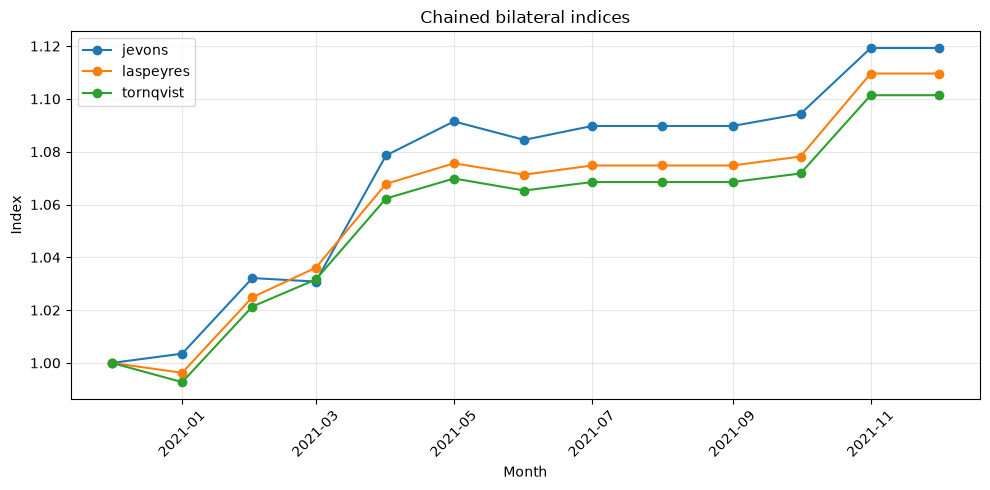

In [11]:
# Visualising the results
fig, ax = plt.subplots(figsize=(10, 5))
for col in ["jevons", "laspeyres", "tornqvist"]:
    ax.plot(index_df["period"], index_df[col], marker="o", label=col)
ax.set_xlabel("Month")
ax.set_ylabel("Index")
ax.set_title("Chained bilateral indices")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Multilateral methods

Bilateral methods compare only two periods at a time. **Multilateral methods** consider all periods within a window simultaneously, which eliminates path-dependence and avoids chain drift. They are particularly suited for high-frequency scanner data.

PyIndexNum multilateral functions require the following columns:

| Column | Type | Description |
|---|---|---|
| `period` | Date | Observation period |
| `product_id` | numeric / character | Product identifier |
| `aggregated_price` | numeric > 0 | Price |
| `aggregated_quantity` | numeric > 0 | Quantity sold |

The functions require a **balanced panel**: each product must appear exactly once in every period. We use `carry_forward_imputation` to fill gaps.


In [12]:
# Prepare data in the format required by multilateral functions
df_ml = data.select([
    pl.col("product_id"),
    pl.col("date").alias("period"),
    pl.col("price").alias("aggregated_price"),
    pl.col("quantity").alias("aggregated_quantity"),
])

# Filter to the first 13 periods and create a balanced panel
window_periods = periods[:13]
df_window = df_ml.filter(pl.col("period").is_in(window_periods))

# Fill missing product-period combinations with imputation
# carry_forward fills gaps with the last observed value
# carry_backward fills any remaining gaps (products appearing late)
df_balanced = pin.carry_forward_imputation(
    df_window, ["aggregated_price", "aggregated_quantity"]
)
df_balanced = pin.carry_backward_imputation(
    df_balanced, ["aggregated_price", "aggregated_quantity"]
)
print(f"Raw rows: {df_window.height}")
print(f"Balanced rows: {df_balanced.height}")
print(f"Products: {df_balanced["product_id"].n_unique()}")

Raw rows: 251
Balanced rows: 481
Products: 37


## GEKS

The **GEKS index** (Gini, Eltetö, Köves, Szulc) is the most widely used multilateral method for scanner data.

**How it works:**

1. Compute all bilateral indices between every pair of periods within the window — an $n \times n$ matrix.
2. For each target period $t$, compute the geometric mean of all two-step paths from the base through every intermediate period $k$:

$$I^{GEKS}_{0,t} = \left(\prod_{k=1}^{n} I_{0,k} \cdot I_{k,t}\right)^{1/n}$$

By averaging over all paths, GEKS reduces the influence of any single period's product composition.

PyIndexNum provides GEKS based on three bilateral formulas: `geks_fisher`, `geks_tornqvist` (equivalent to CCDI), and `geks_jevons` (unweighted).


In [13]:
# GEKS-Törnqvist (equivalent to CCDI in PriceIndices)
geks_t = pin.geks_tornqvist(df_balanced)
geks_t

period,index_value
date,f64
2020-12-01,1.0
2021-01-01,0.996561
2021-02-01,1.016304
2021-03-01,1.020188
2021-04-01,1.03959
…,…
2021-08-01,1.042654
2021-09-01,1.041595
2021-10-01,1.042781


In [14]:
# GEKS-Fisher
geks_f = pin.geks_fisher(df_balanced)
geks_f

period,index_value
date,f64
2020-12-01,1.0
2021-01-01,0.996647
2021-02-01,1.016382
2021-03-01,1.02017
2021-04-01,1.039631
…,…
2021-08-01,1.042689
2021-09-01,1.041578
2021-10-01,1.042728


In [15]:
# Compare the two GEKS variants
geks_comparison = geks_t.rename({"index_value": "GEKS-Törnqvist"}).join(
    geks_f.rename({"index_value": "GEKS-Fisher"}), on="period"
)
geks_comparison

period,GEKS-Törnqvist,GEKS-Fisher
date,f64,f64
2020-12-01,1.0,1.0
2021-01-01,0.996561,0.996647
2021-02-01,1.016304,1.016382
2021-03-01,1.020188,1.02017
2021-04-01,1.03959,1.039631
…,…,…
2021-08-01,1.042654,1.042689
2021-09-01,1.041595,1.041578
2021-10-01,1.042781,1.042728


## Geary-Khamis

The **Geary-Khamis (GK) method** simultaneously estimates a quality-adjusted reference price $v_i$ for each product and a price level index $P_t$ for each period. The system gets solved iteratively:

$$v_i = \sum_t \frac{q_{it}}{\sum_s q_{is}} \cdot \frac{p_{it}}{P_t} \qquad P_t = \frac{\sum_i p_{it} q_{it}}{\sum_i v_i q_{it}}$$

Starting from $v_i = 1$, we alternate between updating $v_i$ and $P_t$ until convergence.


In [16]:
# Geary-Khamis index
gk = pin.geary_khamis(df_balanced)
gk

period,index_value
date,f64
2020-12-01,1.0
2021-01-01,0.995372
2021-02-01,1.015453
2021-03-01,1.01977
2021-04-01,1.039422
…,…
2021-08-01,1.04252
2021-09-01,1.041171
2021-10-01,1.04261


## Time Product Dummy (TPD)

The **TPD method** estimates the price index via regression. Log price is regressed on time dummies and product dummies:

$$\log(p_{it}) = \alpha + \sum_t \beta_t \cdot \mathbf{1}[period=t] + \sum_i \gamma_i \cdot \mathbf{1}[product=i] + \varepsilon_{it}$$

The exponentiated time coefficients $e^{\hat{\beta}_t}$ give the price index. Weighting by expenditure share gives more influence to important products.

PyIndexNum supports both weighted (`weighted=True`, the default) and unweighted (`weighted=False`) TPD.


In [17]:
# Weighted TPD (WTPD) index
tpd = pin.time_product_dummy(df_balanced, weighted=True)
tpd

period,index_value
date,f64
2020-12-01,1.0
2021-01-01,0.995057
2021-02-01,1.01474
2021-03-01,1.019035
2021-04-01,1.038288
…,…
2021-08-01,1.041332
2021-09-01,1.040345
2021-10-01,1.041832


In [18]:
# Compare all multilateral methods
multilateral = (
    geks_t.rename({"index_value": "GEKS-Törnqvist"})
    .join(gk.rename({"index_value": "Geary-Khamis"}), on="period")
    .join(tpd.rename({"index_value": "TPD"}), on="period")
)
multilateral

period,GEKS-Törnqvist,Geary-Khamis,TPD
date,f64,f64,f64
2020-12-01,1.0,1.0,1.0
2021-01-01,0.996561,0.995372,0.995057
2021-02-01,1.016304,1.015453,1.01474
2021-03-01,1.020188,1.01977,1.019035
2021-04-01,1.03959,1.039422,1.038288
…,…,…,…
2021-08-01,1.042654,1.04252,1.041332
2021-09-01,1.041595,1.041171,1.040345
2021-10-01,1.042781,1.04261,1.041832


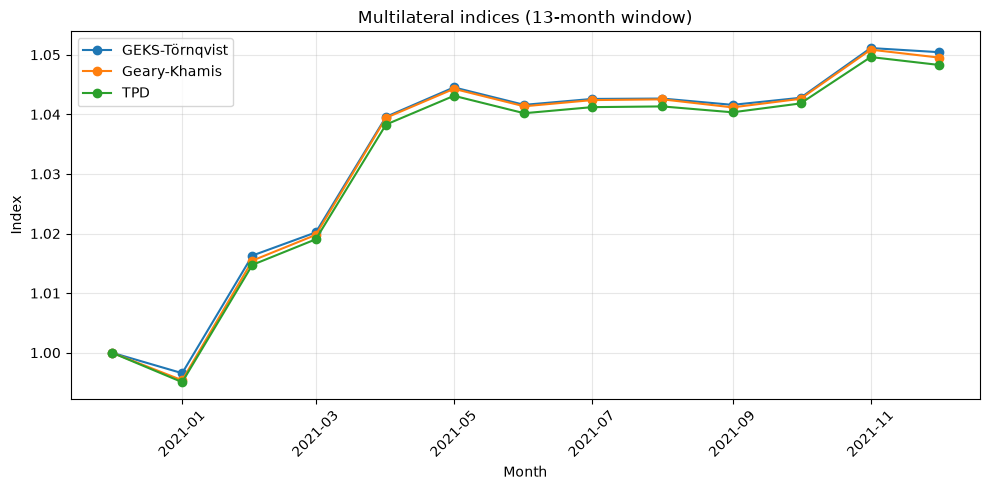

In [19]:
# Visualising the results
fig, ax = plt.subplots(figsize=(10, 5))
for col in ["GEKS-Törnqvist", "Geary-Khamis", "TPD"]:
    ax.plot(multilateral["period"], multilateral[col], marker="o", label=col)
ax.set_xlabel("Month")
ax.set_ylabel("Index")
ax.set_title("Multilateral indices (13-month window)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Extending the index: splicing methods

Multilateral indices are computed on a fixed window (e.g. 13 months). To extend the series beyond the initial window, we use **splicing methods**: each time a new period arrives, we compute a new multilateral index on a shifted window and connect it to the published series.

PyIndexNum provides four splicing methods:

- **Movement splice** — uses the movement between the last two periods of the new window
- **Window splice** — uses the movement between the first and last period of the new window
- **Half splice** — uses the movement from the middle period of the window
- **Mean splice** — geometric mean of all overlapping-period splices

Each splicing function takes two index DataFrames (the previous window and the new shifted window) and returns the previous index plus the spliced new period.


In [20]:
def extend_multilateral(df, method_func, splice_func, window=13):
    """
    Compute a multilateral index and extend it beyond the initial window
    using splicing.

    Parameters
    ----------
    df : DataFrame with product_id, period, aggregated_price, aggregated_quantity
    method_func : e.g. pin.geks_tornqvist
    splice_func : e.g. pin.movement_splice
    window : window length (default 13)
    """
    all_periods = sorted(df["period"].unique().to_list())

    # Initial window
    w0_raw = df.filter(pl.col("period").is_in(all_periods[:window]))
    w0 = pin.carry_forward_imputation(w0_raw, ["aggregated_price", "aggregated_quantity"])
    w0 = pin.carry_backward_imputation(w0, ["aggregated_price", "aggregated_quantity"])
    result = method_func(w0)

    # Extend for each subsequent period
    for i in range(1, len(all_periods) - window + 1):
        prev_raw = df.filter(pl.col("period").is_in(all_periods[i - 1 : i - 1 + window]))
        prev = pin.carry_forward_imputation(prev_raw, ["aggregated_price", "aggregated_quantity"])
        prev = pin.carry_backward_imputation(prev, ["aggregated_price", "aggregated_quantity"])

        new_raw = df.filter(pl.col("period").is_in(all_periods[i : i + window]))
        new = pin.carry_forward_imputation(new_raw, ["aggregated_price", "aggregated_quantity"])
        new = pin.carry_backward_imputation(new, ["aggregated_price", "aggregated_quantity"])

        prev_idx = method_func(prev)
        new_idx = method_func(new)

        spliced = splice_func(prev_idx, new_idx)
        result = pl.concat([result, spliced.tail(1)])

    return result

In [21]:
# Extend the GEKS-Törnqvist index over the full sample using each splice method
extended_movement = extend_multilateral(df_ml, pin.geks_tornqvist, pin.movement_splice)
extended_mean     = extend_multilateral(df_ml, pin.geks_tornqvist, pin.mean_splice)
extended_half     = extend_multilateral(df_ml, pin.geks_tornqvist, pin.half_splice)
extended_window   = extend_multilateral(df_ml, pin.geks_tornqvist, pin.window_splice)

splices = (
    extended_movement.rename({"index_value": "movement splice"})
    .join(extended_mean.rename({"index_value": "mean splice"}), on="period")
    .join(extended_half.rename({"index_value": "half splice"}), on="period")
    .join(extended_window.rename({"index_value": "window splice"}), on="period")
)
splices

period,movement splice,mean splice,half splice,window splice
date,f64,f64,f64,f64
2020-12-01,1.0,1.0,1.0,1.0
2021-01-01,0.996561,0.996561,0.996561,0.996561
2021-02-01,1.016304,1.016304,1.016304,1.016304
2021-03-01,1.020188,1.020188,1.020188,1.020188
2021-04-01,1.03959,1.03959,1.03959,1.03959
…,…,…,…,…
2022-12-01,1.000468,1.000062,1.000291,1.000551
2023-01-01,1.000324,1.000268,1.000228,1.000247
2023-02-01,0.995783,0.997428,0.996864,1.001655


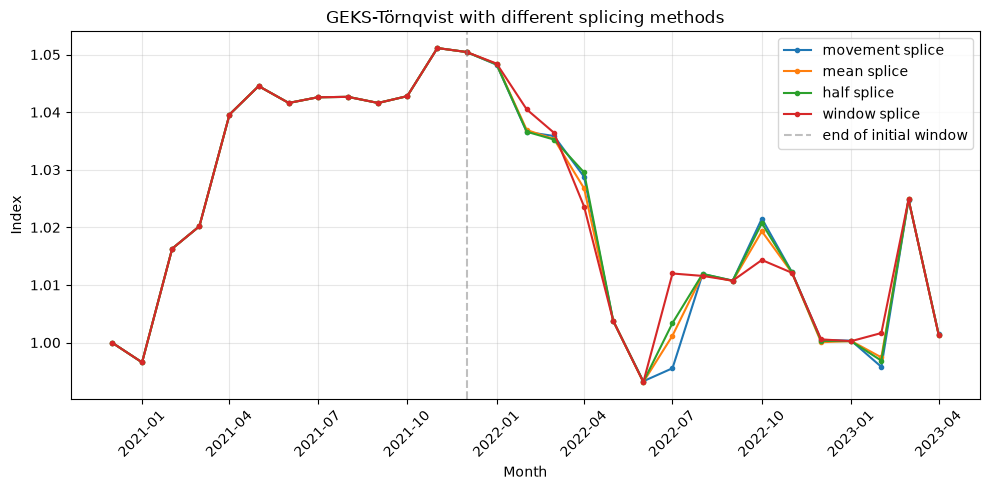

In [22]:
# Visualising the results
fig, ax = plt.subplots(figsize=(10, 5))
for col in ["movement splice", "mean splice", "half splice", "window splice"]:
    ax.plot(splices["period"], splices[col], marker="o", markersize=3, label=col)
ax.axvline(periods[12], color="grey", linestyle="--", alpha=0.5, label="end of initial window")
ax.set_xlabel("Month")
ax.set_ylabel("Index")
ax.set_title("GEKS-Törnqvist with different splicing methods")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()